
# 14. 새 능력의 모양 스스로 찾기

**문제 흐름** (예고 없음, 70구간 × 200문제): 기존 → + 새 말투 → + **다음 차례**(해 → 달 → 별 → 해) → + **맞바꿈**(해 ↔ 별, 달 그대로)

**8단계와 다른 점**: 8단계에서는 새 가지의 모양("열쇠를 한 칸 돌리기")을 사람이 정해 줬다. 이번에는 시스템이 **가설을 세우고 시험해서** 모양을 고른다.

| 방식 | 새 가지의 모양 |
|---|---|
| 안 키움 | — |
| 모양 고정 | 사람이 준 "한 칸 돌리기"만 |
| **가설 탐색 (우리)** | 열쇠 3개를 재배치하는 6가지 + "방금 키운 가지를 더 공부하기"를 다 시험해서 고름 |
| 정답 모양 | 각 관계의 정답 모양을 앎 |

성장 시점(실패율 2구간 연속 5% 초과), 공부 자료(오답노트 + 복습)는 모든 방식이 같다.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
SEEDS = (45, 46, 47)
POLICIES = [("never", "안 키움", V.NEUTRAL), ("fixed", "모양 고정", V.ORANGE), ("search", "가설 탐색 (우리)", V.BLUE), ("oracle", "정답 모양", V.MUTED)]
runs = {(p, s): json.loads((S.RESULTS / f"world-v9_stream_{p}_seed-{s}.json").read_text(encoding="utf-8")) for p, _, _ in POLICIES for s in SEEDS}
def late(p, s, family=None):
    blocks = [e for e in runs[(p, s)]["blocks"] if e["block"] >= 66]
    return np.mean([e["by_family"][family] if family else e["score"] for e in blocks])
for s in SEEDS:
    print(s, {p: round(late(p, s), 3) for p, _, _ in POLICIES}, [(g["decided_at"], g["chosen"]) for g in runs[("search", s)]["growths"]])


45 {'never': np.float64(0.603), 'fixed': np.float64(0.789), 'search': np.float64(0.991), 'oracle': np.float64(0.983)} [(22, [1, 2, 0]), (37, [2, 1, 0]), (47, 'refine')]
46 {'never': np.float64(0.591), 'fixed': np.float64(0.788), 'search': np.float64(0.964), 'oracle': np.float64(0.988)} [(22, [1, 2, 0]), (37, 'refine'), (47, [2, 1, 0])]
47 {'never': np.float64(0.518), 'fixed': np.float64(0.711), 'search': np.float64(0.952), 'oracle': np.float64(0.784)} [(22, [1, 2, 0]), (37, [2, 1, 0]), (47, 'refine'), (57, 'refine')]



## 1. 마지막 구간(66–70) 점수


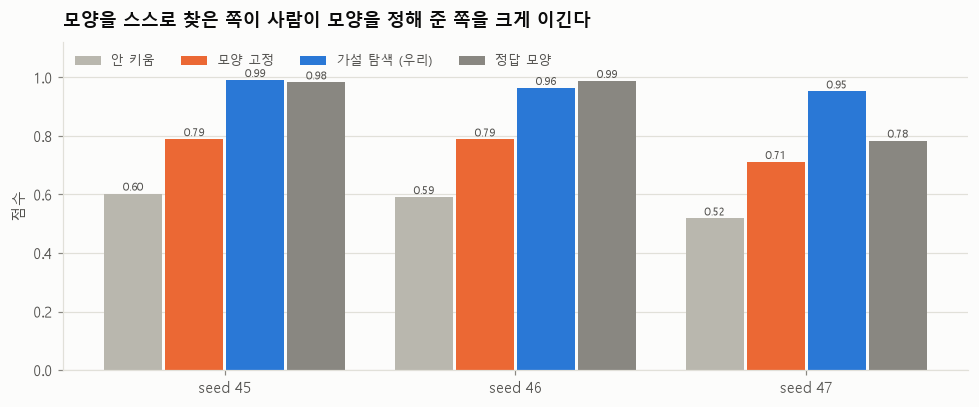

In [2]:

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(SEEDS))
w = 0.2
for i, (p, label, color) in enumerate(POLICIES):
    values = [late(p, s) for s in SEEDS]
    ax.bar(x + (i - 1.5) * (w + 0.01), values, width=w, color=color, label=label)
    for xi, v in zip(x, values):
        ax.text(xi + (i - 1.5) * (w + 0.01), v + 0.01, f"{v:.2f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
ax.set_ylim(0, 1.12)
ax.grid(axis="x", visible=False)
ax.set_ylabel("점수")
ax.legend(fontsize=8.5, frameon=False, ncol=4, loc="upper left")
ax.set_title("모양을 스스로 찾은 쪽이 사람이 모양을 정해 준 쪽을 크게 이긴다", pad=10)
fig.tight_layout()
plt.show()



## 2. 맞바꿈 문제만 따로 (66–70)

모양 고정은 "한 칸 돌리기" 말고는 몰라서 맞바꿈 앞에서 "더 공부하기"만 반복했다.


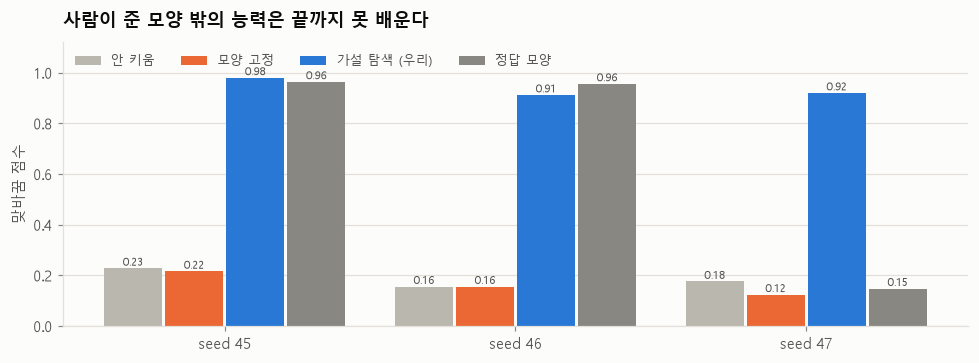

In [3]:

fig, ax = plt.subplots(figsize=(9, 3.4))
for i, (p, label, color) in enumerate(POLICIES):
    values = [late(p, s, "swap") for s in SEEDS]
    ax.bar(x + (i - 1.5) * (w + 0.01), values, width=w, color=color, label=label)
    for xi, v in zip(x, values):
        ax.text(xi + (i - 1.5) * (w + 0.01), v + 0.01, f"{v:.2f}", ha="center", fontsize=7.5, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
ax.set_ylim(0, 1.12)
ax.grid(axis="x", visible=False)
ax.set_ylabel("맞바꿈 점수")
ax.legend(fontsize=8.5, frameon=False, ncol=4, loc="upper left")
ax.set_title("사람이 준 모양 밖의 능력은 끝까지 못 배운다", pad=10)
fig.tight_layout()
plt.show()



## 3. 흐름 따라 보기 (seed 46, 가설 탐색)

점선이 성장 결정 시점이다. 37구간에서 맞바꿈이 처음 나오자 먼저 "더 공부하기"를 골랐다. 그래도 안 풀리자 47구간에서 해↔별을 찾았다.


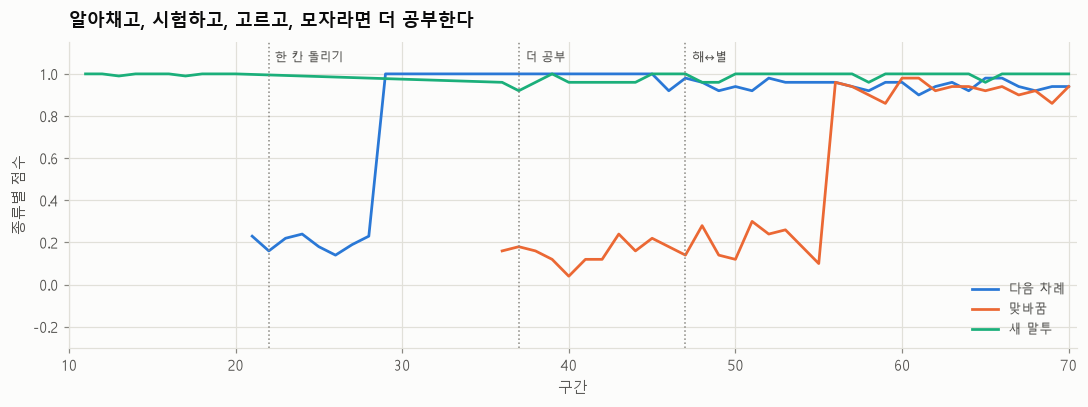

In [4]:

r = runs[("search", 46)]
fig, ax = plt.subplots(figsize=(10, 3.8))
for family, label, color in [("next", "다음 차례", V.BLUE), ("swap", "맞바꿈", V.ORANGE), ("same-new", "새 말투", V.AQUA)]:
    pts = [(e["block"], e["by_family"][family]) for e in r["blocks"] if family in e["by_family"]]
    ax.plot([p[0] for p in pts], [p[1] for p in pts], color=color, lw=1.8, label=label)
for g in r["growths"]:
    ax.axvline(g["decided_at"], color=V.MUTED, ls=":", lw=1)
    name = "더 공부" if g["chosen"] == "refine" else ("한 칸 돌리기" if g["chosen"] in ([1, 2, 0], [2, 0, 1]) else "해↔별")
    ax.text(g["decided_at"] + 0.4, 1.06, name, fontsize=8, color=V.TEXT_SECONDARY)
ax.set_xlim(10, 70.5)
ax.set_ylim(-0.3, 1.15)
ax.set_xlabel("구간")
ax.set_ylabel("종류별 점수")
ax.legend(fontsize=8.5, frameon=False, loc="lower right")
ax.set_title("알아채고, 시험하고, 고르고, 모자라면 더 공부한다", pad=10)
fig.tight_layout()
plt.show()



## 4. 정리

- **졸업.** 세 seed 모두 22구간에 "한 칸 돌리기", 37 또는 47구간에 "해↔별"을 스스로 골랐다. 66–70구간 점수는 0.991 / 0.964 / 0.952로, 모양 고정(0.789 / 0.788 / 0.711)보다 평균 +0.21 높다. 정답 모양을 아는 기준선과 비슷하거나 높다.
- **분석에서 배운 것**: 기울기로 조금씩 고치는 학습은 새 규칙의 모양을 찾지 못한다("그대로 전달"에 갇힘). **가설을 세우고 시험해서 고르는** 과학적 방법이 통했다.
- **설계하다 배운 것**:
  1. 처음 보는 문장을 기존 가지가 가로챈다 → 문장 하나 = 관계 하나로 경쟁시킨다.
  2. 새 개념이 생기면 **기존 개념의 경계도 다시 그어야** 한다. 기존 가지의 관계 문만 같이 조정한다.
  3. 틀린 문제 위주로 공부한다(오답노트).
  4. "새 개념이 필요한가, 연습이 더 필요한가"도 가설로 시험한다.
- **솔직한 점**: 정답 모양 seed 47은 맞바꿈을 못 배웠다(0.15). 가지 학습이 시작값에 따라 실패할 수 있다. 가설 탐색은 여러 번 학습하는 효과도 있으니, 이득의 일부는 "여러 번 시도"에서 온다.
- 한계: 가설 공간(6가지 재배치 + 더 공부)은 사람이 정했다.
